# NEM-reliability-suite - Example

This example presents a (very) small workflow to help users get some understanding of the setup of the packages. It is built upon the the datasets in the folder `/data`. 

A full example on how to use the functionalities can be found in `AR-PST Final Report - Tutorial.ipynb`.

We start by importing packages and defining the parameters of the study:

In [ ]:
# If not already done, activate and instantiate the local environment before running this script:
#using Pkg; Pkg.activate("."); Pkg.instantiate()

# Import necessary packages
#using PISP # PISP not necessary since the dataset is already created
using PRASNEM
using Dates
using SchedNEM
using HiGHS
using Dates
using PRAS
using StatsPlots
using Statistics


# The path to the PISP dataset
pisp_path = joinpath(@__DIR__, "..", "data", "pisp-datasets", "out-ref2017-poe10", "csv")
# Specify the folder within the PISP dataset that contains the timeseries data
timeseries_folder = "schedule-09022040-11022040"

# Define the start and end datetimes for the timeseries data
start_dt = DateTime(2040, 2, 9, 0, 0, 0)
end_dt = DateTime(2040, 2, 11, 23, 0, 0)

# Get default parameters for the PRAS system creation
line_buildout = PRASNEM.get_added_lines_per_year()
DER_parameters = PRASNEM.get_DER_parameters(; case="base") # Adding 50% of forecased VPP for this example. Can specify various cases, see function for details (e.g. "base", "baseVPP", "baseDR")
hydro_parameters = PRASNEM.get_hydro_parameters();


#### Part 1: Create PRAS system


In [31]:
# Now create the PRAS files from the PISP dataset
sys = PRASNEM.create_pras_system(start_dt, end_dt, pisp_path, timeseries_folder; 
                                line_alias_included=line_buildout[year(start_dt)],
                                hydro_parameters=hydro_parameters,
                                DER_parameters=DER_parameters)

# To use the whole workflow, we need to derate storage unit capacity and remove explicit storage unit operation
PRASNEM.updateStorageOutageDerating!(sys);

┌ Info: Creating PRAS file from input data...
│ Scenario: 2
│ Regions: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12
│ Timeseries: 2040-02-09T00:00:00 to 2040-02-11T23:00:00
│ Excluded tech/fuel: DSP, EV, VPP
│ Excluded aliases: None
│ Additional lines included: NL_86_INV30, NL_67_INV19, NL_23_INV3, VNI North, VNI South, NL_98_INV34, NL_65_INV14, NL_109_INV35, NL_42_INV8, NL_109_INV36, NL_54_INV10, NL_65_INV15
│ DER considered: RoofPV
│ Input folder: c:\Users\tkopka\OneDrive - The University of Melbourne\Documents\PROGRAMMING\PROJECT - CSIRO ARPST\NEM-reliability-suite\tutorials\..\data\pisp-datasets\out-ref2017-poe10\csv\schedule-09022040-11022040
└ @ PRASNEM C:\Users\tkopka\.julia\packages\PRASNEM\RZsu4\src\parser\core.jl:181
┌ Info: PRAS system successfully created.
└ @ PRASNEM C:\Users\tkopka\.julia\packages\PRASNEM\RZsu4\src\parser\core.jl:230


### Part 2: Schedule the system with SchedNEM

In [32]:
# Create tge solver instance for the optimisation problem
solver_instance = HiGHS.Optimizer()

# Build the JuMP optimisation model
m = SchedNEM.build_operation_model(sys; input_folder=pisp_path, 
   optimiser=solver_instance,
   hydro_parameters=hydro_parameters,
   DER_parameters=DER_parameters)

# Solve the optimisation problem
sched = SchedNEM.run_operation_model(m, sys);

┌ Info: Running operation model with rolling horizon optimisation... 
│ Optimisation window: 48 | Move forward step: 24 
│ Timesteps: 1 to 72 
│ Ramping: true | UC: true | Binary: false 
│ Reserve run: true
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\model\core.jl:162
┌ Warning: Load shedding is occurring in simulation 1-48: 11021.11 MWh.
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\model\core.jl:275


Optimisation progress: Time step 49 of 72


┌ Warning: Load shedding is occurring in simulation 25-72: 15539.79 MWh.
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\model\core.jl:275
┌ Warning: Load shedding is occurring in simulation 49-72: 4518.68 MWh.
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\model\core.jl:275
┌ Warning: Hydro spillage is occurring in simulation 49-72: 816.0 MWh.
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\model\core.jl:279


### Step 3: Evaluate the system against outages (PRAS)

In [33]:
# Create a system with derated energy capacity (approximation 2)
sys_derated = deepcopy(sys)
PRASNEM.updateEnergyDerating!(sys_derated)

# Create a system with the expected dispatch of DR, storage and unit commitment
sys_assessment = deepcopy(sys)
PRASNEM.updateDRExpectationDispatch!(sys_assessment, sched)
PRASNEM.updateStorageExpectationDispatch!(sys_assessment, sched)
PRASNEM.updateUnitCommitment!(sys_assessment, sched);

┌ Info: <1.5 hours large-scale energy storage derated to 50.0% capacity (excl. VPPs).
└ @ PRASNEM C:\Users\tkopka\.julia\packages\PRASNEM\RZsu4\src\updating\updateStorageOperation.jl:21
┌ Info: <3.5 hours large-scale energy storage derated to 75.0% capacity (excl. VPPs).
└ @ PRASNEM C:\Users\tkopka\.julia\packages\PRASNEM\RZsu4\src\updating\updateStorageOperation.jl:21
┌ Info: <7.5 hours large-scale energy storage derated to 90.0% capacity (excl. VPPs).
└ @ PRASNEM C:\Users\tkopka\.julia\packages\PRASNEM\RZsu4\src\updating\updateStorageOperation.jl:21
┌ Info: No demand response resources, skipping updateDRExpectationDispatch!
└ @ PRASNEM C:\Users\tkopka\.julia\packages\PRASNEM\RZsu4\src\updating\updateDEROperation.jl:21


In [ ]:
# Define the PRAS assessment specifications
nsamples = 100
simspecs = SequentialMonteCarlo(samples=nsamples, seed=1)
resspecs = (ShortfallSamples(),)

# Run the assessment with the different systems
sfsamples_greedy, = assess(sys, simspecs, resspecs...)
sfsamples_derated, = assess(sys_derated, simspecs, resspecs...)
sfsamples_expected, genAv, lineAv = assess(sys_assessment, simspecs, ShortfallSamples(), GeneratorAvailability(), LineAvailability());

In [35]:
println("High energy results: ", NEUE(sfsamples_greedy))
println("Derated energy results: ", NEUE(sfsamples_derated))
println("Expected dispatch results: ", NEUE(sfsamples_expected))

High energy results: NEUE = 7200±100 ppm
Derated energy results: NEUE = 9100±100 ppm
Expected dispatch results: NEUE = 8900±200 ppm


#### Step 4: Run reoptimisation with the expected dispatch results

In [36]:
sf_new = SchedNEM.reoptimise(PRASNEM.get_all_event_details(sfsamples_expected), sys, sched, genAv.available, lineAv.available; 
                DER_parameters=DER_parameters,
                hydro_parameters=hydro_parameters,
                optimiser_name="HiGHS", input_folder=pisp_path);

┌ Info: Reoptimising all events with a horizon of > 4 hours to assess system response.
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\reoptimisation\reoptimise.jl:43
┌ Info: Running the re-optimisation with imperfect foresight now for 100 samples...
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\reoptimisation\reoptimise.jl:86


     1/100
     2/100
     3/100
     4/100
     5/100
     6/100
     7/100
     8/100
     9/100
     10/100
     11/100
     12/100
     13/100
     14/100
     15/100
     16/100
     17/100
     18/100
     19/100
     20/100
     21/100
     22/100
     23/100
     24/100
     25/100
     26/100
     27/100
     28/100
     29/100
     30/100
     31/100
     32/100
     33/100
     34/100
     35/100
     36/100
     37/100
     38/100
     39/100
     40/100
     41/100
     42/100
     43/100
     44/100
     45/100
     46/100
     47/100
     48/100
     49/100
     50/100
     51/100
     52/100
     53/100
     54/100
     55/100
     56/100
     57/100
     58/100
     59/100
     60/100
     61/100
     62/100
     63/100
     64/100
     65/100
     66/100
     67/100
     68/100
     69/100
     70/100
     71/100
     72/100
     73/100
     74/100
     75/100
     76/100
     77/100
     78/100
     79/100
     80/100
     81/100
     82/100
     83/100
     84/100
 

┌ Info: Re-optimisation completed.
│      Total number of simulations: 256
│      + extended simulations: 0.
└ @ SchedNEM C:\Users\tkopka\.julia\packages\SchedNEM\LTjkH\src\reoptimisation\reoptimise.jl:194


### Step 5: Visualising


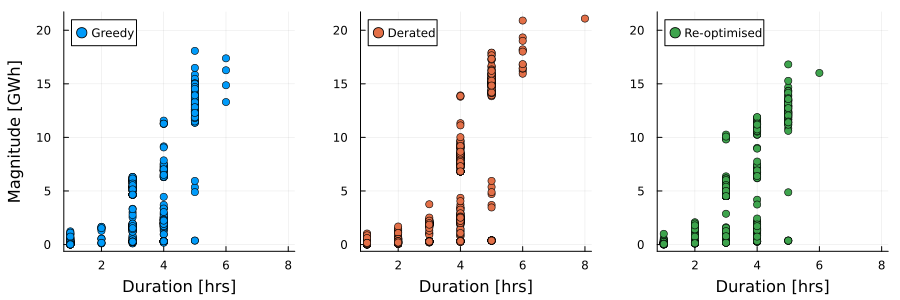

In [139]:
# Risk profile of these three days (without any DER!)

ev_greedy = PRASNEM.get_all_event_details(sfsamples_greedy)
ev_derated = PRASNEM.get_all_event_details(sfsamples_derated)
ev_reoptimised = PRASNEM.get_all_event_details(sf_new)

p1 = scatter(ev_greedy.length, ev_greedy.sum ./ 1e3, label="Greedy", c=1, ylabel="Magnitude [GWh]")
p2 = scatter(ev_derated.length, ev_derated.sum ./ 1e3, label="Derated", c=2)
p3 = scatter(ev_reoptimised.length, ev_reoptimised.sum ./ 1e3, label="Re-optimised", c=3)

plot(p1, p2, p3, layout=(1,3), xlabel="Duration [hrs]", title="", legend=:topleft, link=:all, 
   size=(900,300), leftmargin=5Plots.mm, bottommargin=5Plots.mm)

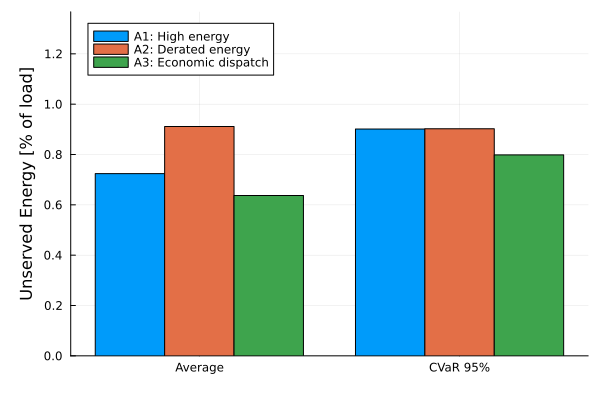

In [102]:
# Metrics

use_per_sample = hcat([sum(sfsamples_greedy.shortfall, dims=[1,2])[:], sum(sfsamples_derated.shortfall, dims=[1,2])[:], sum(sf_new, dims=[1,2])[:]]...) ./ sum(sys.regions.load) * 1e2
average_use = mean(use_per_sample, dims=1)[:]
var_use_per_sample = [quantile(use_per_sample[1, :], 0.95), quantile(use_per_sample[2, :], 0.95), quantile(use_per_sample[3, :], 0.95)]
cvar_use_per_sample = [mean(use_per_sample[1, use_per_sample[1, :] .>= var_use_per_sample[1]]), mean(use_per_sample[2, use_per_sample[2, :] .>= var_use_per_sample[2]]), mean(use_per_sample[3, use_per_sample[3, :] .>= var_use_per_sample[3]])]


groupedbar(hcat(average_use[:], cvar_use_per_sample)', bar_position=:dodge, ylabel="Unserved Energy [% of load]",
   labels=["A1: High energy" "A2: Derated energy" "A3: Economic dispatch"], legend=:topleft,
   size=(600,400), leftmargin=5Plots.mm, bottommargin=5Plots.mm)
xticks!(1:2, ["Average", "CVaR 95%"])
ylims!(0, maximum(vcat(cvar_use_per_sample, average_use)) * 1.5)

Note that these results are conditional for these three days (which are defined by a heatwave, see report). As PRAS is optimised for computational efficiency, dispatch follows heuristics without intertemporal constraints. SchedNEM.jl captures storage arbitrage and unit commitment across the whole optimisation horizon, however, at the expense of longer run-times.

Additionally, especially in highly unreliable systems with many similar sized storage units, the PRAS dispatch may lead to higher levels of load shedding then the full workflow with SchedNEM due to the lack of inter-temporal foresight - e.g. SchedNEM may choose to charge storage units from pumped hydro units to prevent unserved energy in later timesteps!




---
# Additional insights

We can investigate the specific dispatch of both packages with the following code snippets.

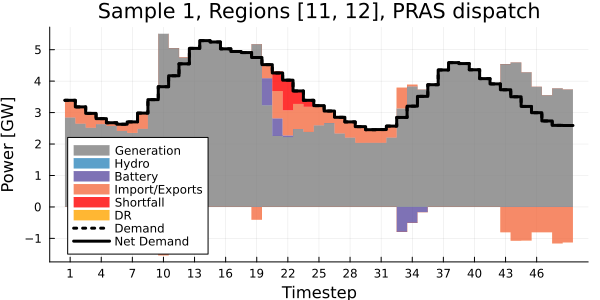

In [ ]:
# PRAS dispatch for one of the samples (e.g. sample 1) for South Australia (regions 11 and 12)
# Arguments: (sys, samples, selected_sample, idx_start, idx_end; seed::Int=1, regions=[], filename="")
PRASNEM.plot_PRAS_dispatch(sys, 10, 1, 24, 72; regions=[11,12])
plot!(size=(600,300), xticks=1:3:48)

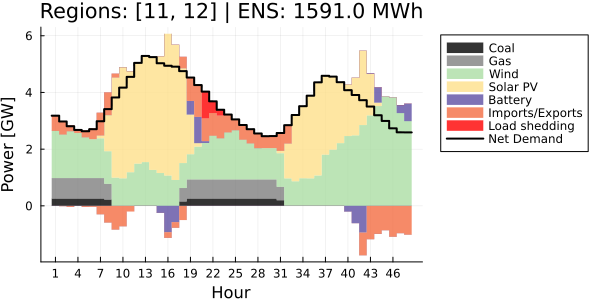

In [138]:
# SchedNEM dispatch for the same sample and regions

m = SchedNEM.build_operation_model(sys; input_folder=pisp_path, 
   optimiser=HiGHS.Optimizer(),
   hydro_parameters=hydro_parameters,
   DER_parameters=DER_parameters)

# Get the initial system conditions from the predispatch (sched) 
initial_soc_stor, initial_soc_genstor, p_gen_initial, 
   gon_initial, stup_before, shdw_before, 
   gen_fail_before = SchedNEM.get_system_parameters(sched, 25, m[:N], m[:genOpDetails], genAv.available[:,:,1])      

SchedNEM.update_model_parameters!(m, sys, 25;
   initial_soc_stor=initial_soc_stor, initial_soc_genstor=initial_soc_genstor,
   p_gen_initial=p_gen_initial, gon_initial=gon_initial, stup_before=stup_before, shdw_before=shdw_before,
   gen_fail_before=gen_fail_before)

SchedNEM.updateGenAvailabilityFullHorizon!(m, genAv.available[:,:,1], 25)
SchedNEM.updateLineAvailabilityFullHorizon!(m, sys, 25, lineAv.available[:,:,1])

optimize!(m)
@assert is_solved_and_feasible(m)

SchedNEM.plot_timeseries_results(m, sys; region=[11,12])
plot!(size=(600,300), xticks=1:3:48)